# Applied Nuclear Data Assimilation using GLLS

This example demonstrates the use of the **Generalized Least Squares (GLLS)** method to improve the prediction of an integral application using experimental benchmark data. 

### 1. Setup and Imports
We use `andalus` for the assimilation logic and `matplotlib` for visualization, `pandas` is used to interact with the data.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

import andalus

### 2. Reading Serpent Output
We use the `AssimilationSuite.from_yaml` method to easily load in a set of benchmarks / applicaitons and covariance information. 

For this example, we limit the assimilation to only U-235 and U-238.

In [2]:
assimilation_suite = andalus.AssimilationSuite.from_yaml("config.yaml")

Reading ../data/hmf001.ser_res.m
  - done
Reading ../data/hmf001.ser_sens0.m
  - done
Reading ../data/hmf002-001.ser_res.m
  - done
Reading ../data/hmf002-001.ser_sens0.m
  - done
Reading ../data/hmf002-002.ser_res.m
  - done
Reading ../data/hmf002-002.ser_sens0.m
  - done


### 3. Energy-Dependent Sensitivities
Visualizing the sensitivity profiles helps us understand which energy ranges drive the $k_{\text{eff}}$ response. Below we compare U-235 fission (MT 18) sensitivities across all systems.

C:\Users\dhouben\Documents\andalus\src\andalus\sensitivity.py:235: PerformanceWarning: indexing past lexsort depth may impact performance.
  subset = self.loc[zai, pert]


[(100.0, 20000000.0)]

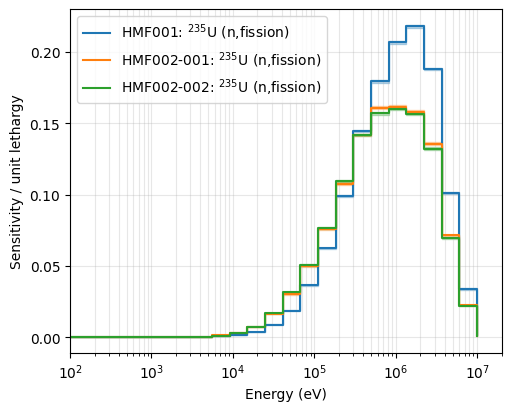

In [3]:
zais = [922350]  # U-235
perts = [18]  # Fission and Capture

fig, ax = plt.subplots(figsize=(5, 4), layout="constrained")

for benchmark in assimilation_suite.benchmarks:
    for zai in zais:
        for pert in perts:
            benchmark.s.plot_sensitivity(zais=[zai], perts=[pert], ax=ax)

assimilation_suite.applications["HMF002-002"].s.plot_sensitivity(zais=zais, perts=perts, ax=ax)

ax.set(
    xlim=(1e2, 2e7),
)

### 4. Similarity Analysis ($c_k$ Index)
The $c_k$ index quantifies the correlation between systems based on shared nuclear data uncertainties. 

$$
c_k=\frac{\text{Cov}(1,2)}{\sqrt(\text{Var}(1)\text{Var}(2))}
$$

Values close to 1.0 indicate that the benchmark is an excellent surrogate for the application.

In [4]:
# Print the ck-similarity matrix
assimilation_suite.ck_matrix()

,HMF001,HMF002-001,HMF002-002
HMF001,1.00000e+00,8.58986e-01,8.61173e-01
HMF002-001,8.58986e-01,1.00000e+00,9.99814e-01
HMF002-002,8.61173e-01,9.99814e-01,1.00000e+00


In [5]:
# Print the ck-similarity values for a specific target
assimilation_suite.ck_target("HMF002-002")

HMF001       8.61173e-01
HMF002-001   9.99814e-01
Name: HMF002-002, dtype: float64

We can see that HMF002-001 shares more than 99% of the nuclear data uncertainties, meaning that if we can the nuclear data uncertainties in HMF002-001, we will also target the nuclear data uncertainties in HMF002-002.

### 5. Performing the GLLS Adjustment
We now calculate the posterior suite. This updates the nominal values ($c$) and reduces the covariance matrix based on the experimental evidence from the benchmarks.

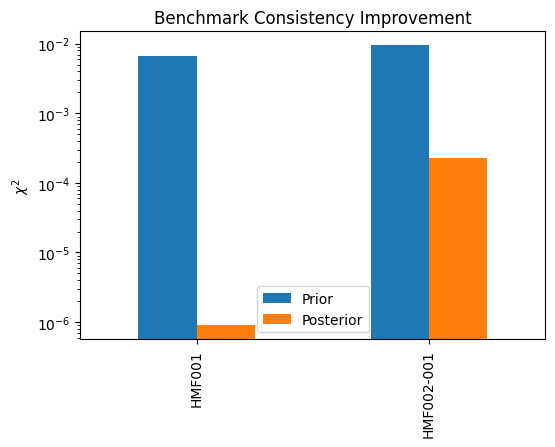

In [6]:
posterior_suite = assimilation_suite.glls()

# Compare Chi-Squared reduction
chi_comparison = pd.DataFrame(
    {
        "Prior": assimilation_suite.individual_chi_squared(nuclear_data=True),
        "Posterior": posterior_suite.individual_chi_squared(nuclear_data=True),
    }
)

ax = chi_comparison.plot.bar(figsize=(6, 4))
ax.set_yscale("log")
ax.set_ylabel("$\\chi^2$")
ax.set_title("Benchmark Consistency Improvement")
plt.show()

### 6. Summary of Results
The plot below shows the $k_{\text{eff}}$ predictions. Note how the **Posterior** values for the target application (HMF002-002) move significantly closer to the experimental measurement, even though that specific system was not used in the adjustment. This is because HMF002-002 is highly similar to HMF002-001, therefore correcting for the behaviour of one improves the prediction for the behaviour of the other one as well.

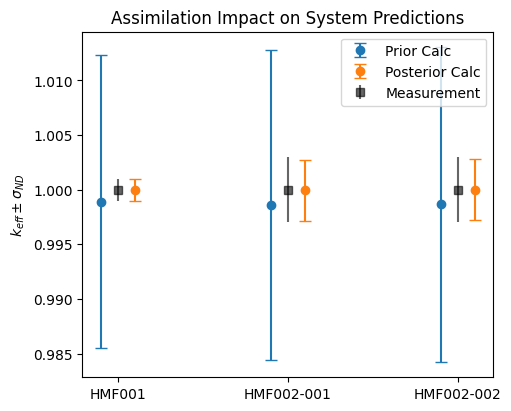

In [8]:
prior_unc = assimilation_suite.propagate_nuclear_data_uncertainty()
post_unc = posterior_suite.propagate_nuclear_data_uncertainty()

fig, ax = plt.subplots(figsize=(5, 4), dpi=100, layout="constrained")

x = range(len(assimilation_suite.titles))
ax.errorbar([i - 0.1 for i in x], assimilation_suite.c, yerr=prior_unc, fmt="o", capsize=4, label="Prior Calc")
ax.errorbar([i + 0.1 for i in x], posterior_suite.c, yerr=post_unc, fmt="o", capsize=4, label="Posterior Calc")
ax.errorbar(
    x,
    assimilation_suite.benchmarks.m.tolist() + [1.00000],
    yerr=assimilation_suite.benchmarks.dm.tolist() + [0.00300],
    fmt="s",
    color="black",
    label="Measurement",
    alpha=0.6,
)

ax.set_xticks(x)
ax.set_xticklabels(assimilation_suite.titles)
ax.set_ylabel("$k_{eff} \\pm \\sigma_{ND}$")
ax.set_title("Assimilation Impact on System Predictions")
ax.legend()
plt.show()